In [28]:
# main_analysis_final_simplified_sankey.py (Updated with consistent naming)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tespy.components import (
    Valve, Sink, Source, Pump, Compressor, Condenser, Turbine, CycleCloser,
    HeatExchanger
)
from tespy.connections import Bus, Connection
from tespy.networks import Network
from tespy.tools import ExergyAnalysis
import CoolProp.CoolProp as CP
import plotly.graph_objects as go

# --- HeatPumpStudy Base Class ---
class HeatPumpStudy:
    def __init__(self, name="HeatPumpStudy", working_fluid="R290", expansion_device="valve", p_amb=1.013):
        self.name = name
        self.working_fluid = working_fluid
        self.expansion_device = expansion_device
        self.p_amb = p_amb
        self.comp = {}
        self.conn = {}
        self.busses = {}
        self.network = None
        self.ean = None
        if self.expansion_device not in ['valve', 'expander']:
            raise ValueError("expansion_device must be 'valve' or 'expander'.")

    def setup_network(self, iterinfo=False):
        self.network = Network(
            fluids=[self.working_fluid, 'Water', 'Air'],
            T_unit='C', p_unit='bar', h_unit='kJ / kg', m_unit='kg / s',
            iterinfo=iterinfo
        )
        self._setup_components_and_connections()
        self.network.add_conns(*list(self.conn.values()))
        return self

    def _setup_components_and_connections(self):
        raise NotImplementedError("This method must be implemented by a subclass.")

    def set_design_parameters(self, **kwargs):
        raise NotImplementedError("This method must be implemented by a subclass.")

    def setup_exergy_analysis(self):
        # The specific components are named in the subclass.
        # Ensure these names align with the subclass's component dictionary keys.
        power = Bus('power_input')
        power.add_comps(
            {'comp': self.comp['main_compressor'], 'base': 'bus'},
            {'comp': self.comp['heating_system_pump'], 'base': 'bus'}
        )
        if self.expansion_device == 'expander':
            power.add_comps({'comp': self.comp['main_expander'], 'base': 'component'})
        
        heat_cons = Bus('heating_system_product')
        heat_cons.add_comps({'comp': self.comp['heating_system_return'], 'base': 'bus'}, {'comp': self.comp['heating_system_feed']})
        
        air_heat = Bus('ambient_air_fuel')
        air_heat.add_comps({'comp': self.comp['ambient_air_source'], 'base': 'bus'}, {'comp': self.comp['ambient_air_sink']})
        
        self.busses = {'power_input': power, 'heating_system_product': heat_cons, 'ambient_air_fuel': air_heat}
        self.network.add_busses(*list(self.busses.values()))
        
        self.ean = ExergyAnalysis(network=self.network, E_F=[power, air_heat], E_P=[heat_cons])

    def solve(self, mode="design", **kwargs):
        if self.network is None:
            raise ValueError("Network not set up.")
        self.network.solve(mode=mode, **kwargs)
        return self

# --- AirSourceHeatPumpStudy Class ---
class AirSourceHeatPumpStudy(HeatPumpStudy):
    def _setup_components_and_connections(self):
        # Component instantiation with new naming
        self.comp['main_condenser'] = Condenser('main_condenser')
        self.comp['main_evaporator'] = HeatExchanger('main_evaporator')
        self.comp['main_compressor'] = Compressor('main_compressor')
        self.comp['refrigerant_cycle_closer'] = CycleCloser('refrigerant_cycle_closer')
        
        if self.expansion_device == 'valve':
            self.comp['main_expansion_valve'] = Valve('main_expansion_valve')
            expansion_comp_name = 'main_expansion_valve'
        else: # expander
            self.comp['main_expander'] = Turbine('main_expander')
            expansion_comp_name = 'main_expander'
            
        self.comp['ambient_air_source'] = Source('ambient_air_source')
        self.comp['ambient_air_sink'] = Sink('ambient_air_sink')
        self.comp['heating_system_return'] = Source('heating_system_return')
        self.comp['heating_system_feed'] = Sink('heating_system_feed')
        self.comp['heating_system_pump'] = Pump('heating_system_pump')

        # Connections with new naming
        self.conn['compressor_to_refrigerant_cycle_closer'] = Connection(
            self.comp['main_compressor'], 'out1', self.comp['refrigerant_cycle_closer'], 'in1'
        )
        self.conn['refrigerant_cycle_closer_to_condenser'] = Connection(
            self.comp['refrigerant_cycle_closer'], 'out1', self.comp['main_condenser'], 'in1'
        )
        self.conn['condenser_to_expansion_device'] = Connection(
            self.comp['main_condenser'], 'out1', self.comp[expansion_comp_name], 'in1'
        )
        self.conn['expansion_device_to_evaporator'] = Connection(
            self.comp[expansion_comp_name], 'out1', self.comp['main_evaporator'], 'in2'
        )
        self.conn['evaporator_to_compressor'] = Connection(
            self.comp['main_evaporator'], 'out2', self.comp['main_compressor'], 'in1'
        )
        
        self.conn['ambient_air_source_to_evaporator'] = Connection(
            self.comp['ambient_air_source'], 'out1', self.comp['main_evaporator'], 'in1'
        )
        self.conn['evaporator_to_ambient_air_sink'] = Connection(
            self.comp['main_evaporator'], 'out1', self.comp['ambient_air_sink'], 'in1'
        )
        
        self.conn['heating_system_return_to_pump'] = Connection(
            self.comp['heating_system_return'], 'out1', self.comp['heating_system_pump'], 'in1'
        )
        self.conn['heating_system_pump_to_condenser'] = Connection(
            self.comp['heating_system_pump'], 'out1', self.comp['main_condenser'], 'in2'
        )
        self.conn['condenser_to_heating_system_feed'] = Connection(
            self.comp['main_condenser'], 'out2', self.comp['heating_system_feed'], 'in1'
        )

    def set_design_parameters(
        self, Q_out, T_air_in, T_hs_mean=40,
        compressor_eta_s=0.8, expander_eta_s=0.8
    ):
        # Component parameterization
        self.comp['main_condenser'].set_attr(pr1=0.99, pr2=0.99, ttd_u=5)
        self.comp['main_evaporator'].set_attr(pr1=0.99, pr2=0.99, ttd_l=5.0)
        self.comp['main_compressor'].set_attr(eta_s=compressor_eta_s)
        self.comp['heating_system_pump'].set_attr(eta_s=0.75)
        if self.expansion_device == 'expander':
            self.comp['main_expander'].set_attr(eta_s=expander_eta_s)

        # Connection parameterization
        self.conn['refrigerant_cycle_closer_to_condenser'].set_attr(fluid={self.working_fluid: 1})
        self.conn['evaporator_to_compressor'].set_attr(Td_bp=3)
        self.conn['condenser_to_heating_system_feed'].set_attr(T=T_hs_mean + 2.5, p=2, fluid={'Water': 1})
        self.conn['heating_system_return_to_pump'].set_attr(T=T_hs_mean - 2.5, p=2)
        self.conn['ambient_air_source_to_evaporator'].set_attr(T=T_air_in, p=self.p_amb, fluid={'Air': 1})
        self.conn['evaporator_to_ambient_air_sink'].set_attr(T=T_air_in - 5.0)
        self.comp['main_condenser'].set_attr(Q=-Q_out)

        # Robust starting values
        T_cond_guess = T_hs_mean + 5
        p_cond_guess = CP.PropsSI('P', 'T', T_cond_guess + 273.15, 'Q', 0, self.working_fluid) / 1e5
        self.conn['refrigerant_cycle_closer_to_condenser'].set_attr(p0=p_cond_guess)
        
        h_cond_out_guess = CP.PropsSI('H', 'P', p_cond_guess * 1e5, 'Q', 0, self.working_fluid) / 1e3
        
        if self.expansion_device == 'valve':
             self.conn['expansion_device_to_evaporator'].set_attr(h0=h_cond_out_guess)
        else: # expander
             # For expander, need an enthalpy at expander outlet that allows for isentropic expansion.
             # This is a bit tricky for an initial guess without iterating,
             # so a rough guess is sufficient as TESPy adjusts.
             # A more robust approach might use a low quality guess, e.g., x=0.01 at evaporator pressure.
             p_evap_guess = CP.PropsSI('P', 'T', T_air_in - 5.0 + 5.0 + 273.15, 'Q', 1, self.working_fluid) / 1e5 # Evap temp from TTD_l
             h_exp_out_guess = CP.PropsSI('H', 'P', p_evap_guess * 1e5, 'Q', 0.1, self.working_fluid) / 1e3
             self.conn['expansion_device_to_evaporator'].set_attr(h0=h_exp_out_guess)


def plot_simplified_sankey(ean_object, title):
    """
    Generates a simplified Sankey chart showing only the distribution of
    exergy destruction among the 4 main cycle components.
    """
    E_D = ean_object.component_data.E_D
    
    # Use the internal TESPy component labels to retrieve destruction values
    # The display names for Sankey nodes can be simpler.
    destructions = {
        'Compressor': E_D.get('main_compressor', 0),
        'Expansion': E_D.get('main_expansion_valve', E_D.get('main_expander', 0)), # Handles both valve and expander
        'Condenser': E_D.get('main_condenser', 0),
        'Evaporator': E_D.get('main_evaporator', 0)
    }
    
    total_destruction = sum(destructions.values())
    
    if total_destruction == 0:
        print(f"Skipping Sankey for '{title}' due to zero total destruction.")
        return

    # Prepare data for Plotly Sankey
    source_indices = [0, 0, 0, 0]
    target_indices = [1, 2, 3, 4]
    values = list(destructions.values())
    
    # Create labels with percentages
    percentages = {key: (val / total_destruction * 100) for key, val in destructions.items()}
    node_labels = [f"Total Cycle Destruction\n({total_destruction:.0f} W)"]
    node_labels += [f"{name}\n({percentages[name]:.1f}%)" for name in destructions.keys()]
    
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node={
            "label": node_labels,
            'pad': 25,
            'thickness': 20,
            'color': ["#333333", "blue", "red", "green", "purple"],
            'line': dict(color="black", width=0.5)
        },
        link={
            "source": source_indices,
            "target": target_indices,
            "value": values
        }
    ))
    fig.update_layout(title_text=title, font_size=12)
    filename = f"{title.replace(' ', '_')}.html"
    fig.write_html(filename)
    print(f"Simplified Sankey chart saved to {filename}")



In [29]:

# --- Shared settings ---
Q_DESIGN = 8000
COMP_ETA_S = 0.7
EXP_ETA_S = 0.7
T_AIR_DESIGN = 7.0
T_AMB_EXERGY_ANALYSIS = T_AIR_DESIGN
T_hs_range = np.arange(35, 66, 5)

results_valve = []
results_expander = []

print("##### Running Multiple Design-Point Study #####")
for temp in T_hs_range:
    print(f"\n--- Designing and analyzing systems for T_hs_mean = {temp}°C ---")
    
    # --- VALVE SYSTEM ---
    hp_valve = AirSourceHeatPumpStudy(name=f'ASHP_Valve_{temp}C', working_fluid='R290', expansion_device='valve')
    hp_valve.setup_network()
    hp_valve.set_design_parameters(Q_out=Q_DESIGN, T_air_in=T_AIR_DESIGN, T_hs_mean=temp, compressor_eta_s=COMP_ETA_S)
    hp_valve.solve('design')
    hp_valve.setup_exergy_analysis()
    hp_valve.ean.analyse(pamb=hp_valve.p_amb, Tamb=T_AMB_EXERGY_ANALYSIS)
    E_D_v = hp_valve.ean.component_data.E_D
    results_valve.append({
        'T_hs_mean': temp,
        'E_D_compressor': E_D_v['main_compressor'],
        'E_D_expansion': E_D_v['main_expansion_valve'],
        'E_D_condenser': E_D_v['main_condenser'],
        'E_D_evaporator': E_D_v['main_evaporator']
    })
    
    # --- EXPANDER SYSTEM ---
    hp_expander = AirSourceHeatPumpStudy(name=f'ASHP_Expander_{temp}C', working_fluid='R290', expansion_device='expander')
    hp_expander.setup_network()
    hp_expander.set_design_parameters(Q_out=Q_DESIGN, T_air_in=T_AIR_DESIGN, T_hs_mean=temp, compressor_eta_s=COMP_ETA_S, expander_eta_s=EXP_ETA_S)
    hp_expander.solve('design')
    hp_expander.setup_exergy_analysis()
    hp_expander.ean.analyse(pamb=hp_expander.p_amb, Tamb=T_AMB_EXERGY_ANALYSIS)
    E_D_e = hp_expander.ean.component_data.E_D
    results_expander.append({
        'T_hs_mean': temp,
        'E_D_compressor': E_D_e['main_compressor'],
        'E_D_expansion': E_D_e['main_expander'], 
        'E_D_condenser': E_D_e['main_condenser'],
        'E_D_evaporator': E_D_e['main_evaporator'],
        'P_compressor': hp_expander.comp['main_compressor'].P.val,
        'P_recovery': abs(hp_expander.comp['main_expander'].P.val)
    })

    if temp in [T_hs_range[0], T_hs_range[-1]]:
        plot_simplified_sankey(hp_valve.ean, f"Simplified Sankey (Valve) Design at {temp}C")
        plot_simplified_sankey(hp_expander.ean, f"Simplified Sankey (Expander) Design at {temp}C")

# --- Convert results to DataFrames and Plot ---
df_valve = pd.DataFrame(results_valve)
df_expander = pd.DataFrame(results_expander)

print("\n--- Final Results (Valve Designs) ---")
print(df_valve.round(2))
print("\n--- Final Results (Expander Designs) ---")
print(df_expander.round(2))



##### Running Multiple Design-Point Study #####

--- Designing and analyzing systems for T_hs_mean = 35°C ---
Simplified Sankey chart saved to Simplified_Sankey_(Valve)_Design_at_35C.html
Simplified Sankey chart saved to Simplified_Sankey_(Expander)_Design_at_35C.html

--- Designing and analyzing systems for T_hs_mean = 40°C ---

--- Designing and analyzing systems for T_hs_mean = 45°C ---

--- Designing and analyzing systems for T_hs_mean = 50°C ---

--- Designing and analyzing systems for T_hs_mean = 55°C ---

--- Designing and analyzing systems for T_hs_mean = 60°C ---

--- Designing and analyzing systems for T_hs_mean = 65°C ---
Simplified Sankey chart saved to Simplified_Sankey_(Valve)_Design_at_65C.html
Simplified Sankey chart saved to Simplified_Sankey_(Expander)_Design_at_65C.html

--- Final Results (Valve Designs) ---
   T_hs_mean  E_D_compressor  E_D_expansion  E_D_condenser  E_D_evaporator
0         35          489.72         267.17         200.07         1158.05
1         4

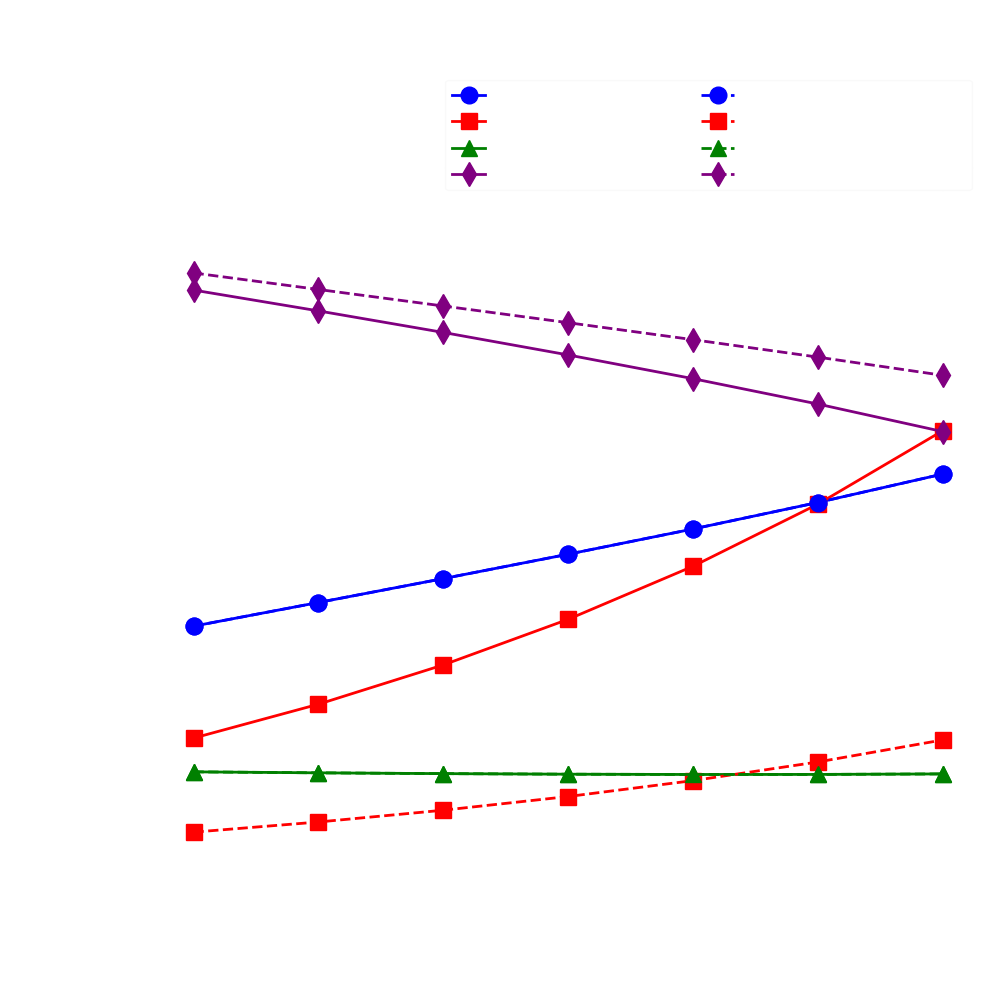

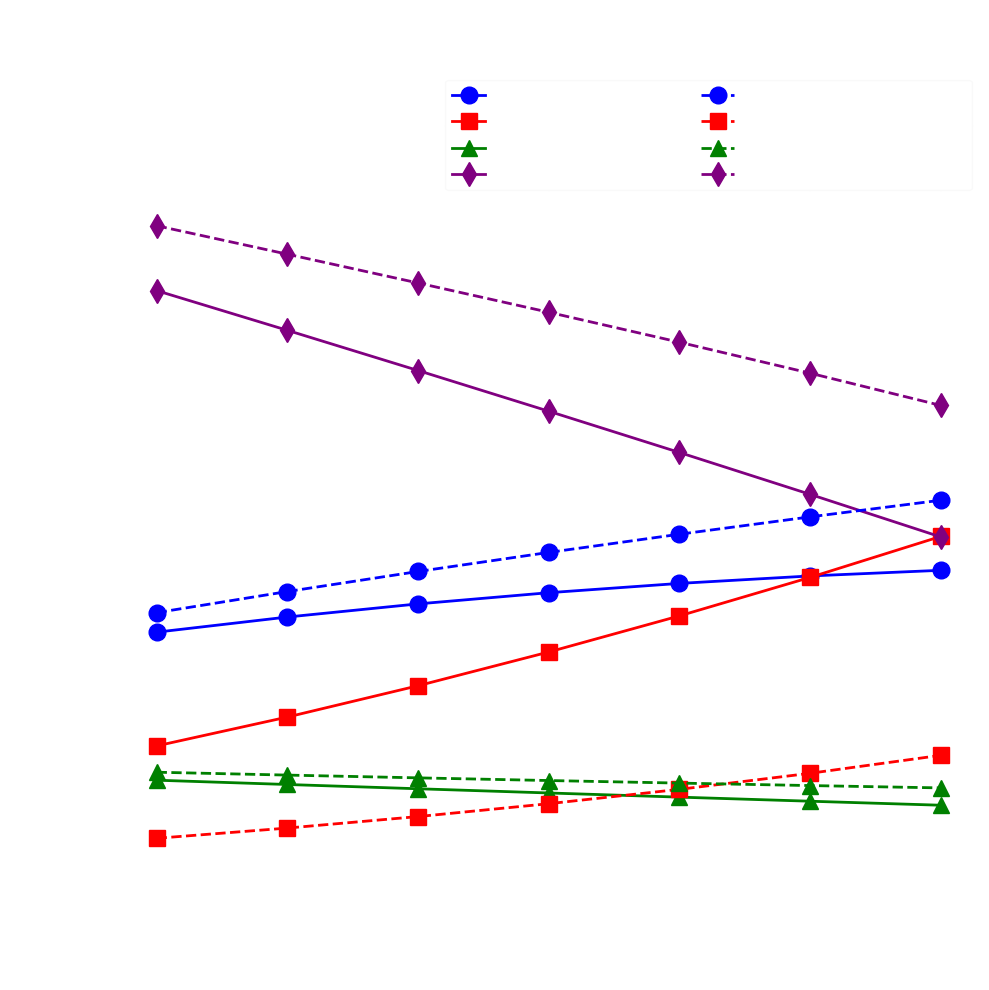

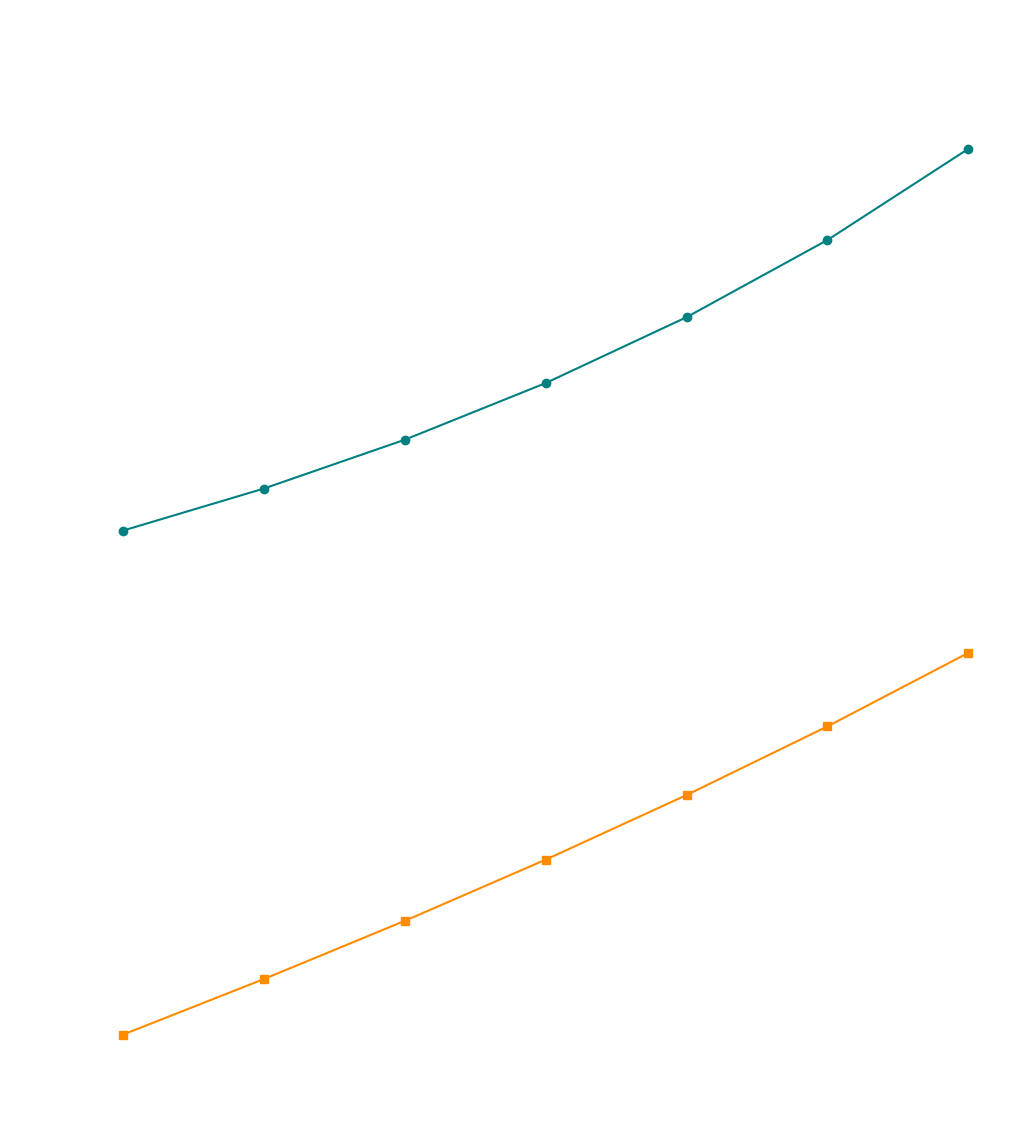

In [31]:

# --- PLOTTING FUNCTIONS (No changes needed in names as they are display labels) ---
def plot_destruction_comparison(df_valve, df_expander, title):
    # --- Optimized for PowerPoint Presentation in German ---
    fig, ax = plt.subplots(figsize=(10, 10))  # Square layout for slides

    # Dark mode and transparent background for overlay on slides
    plt.style.use('dark_background')
    plt.rcParams['axes.facecolor'] = 'none'
    plt.rcParams['figure.facecolor'] = 'none'

    # Add context about ambient temperature and design output in German
    ax.text(
        0.01, 0.98,
        f"Außentemperatur: {T_AMB_EXERGY_ANALYSIS:.1f} °C\nHeizleistung: {Q_DESIGN} W",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(facecolor='white', alpha=0.1, edgecolor='none')
    )

    # Plot with larger markers and thicker lines for visibility
    df_valve.plot(
        x='T_hs_mean', y='E_D_compressor', ax=ax,
        label='Verdichter (Ventil)', marker='o', color='blue', linestyle='-', linewidth=2, markersize=12
    )
    df_valve.plot(
        x='T_hs_mean', y='E_D_expansion', ax=ax,
        label='Expansion (Ventil)', marker='s', color='red', linestyle='-', linewidth=2, markersize=12
    )
    df_valve.plot(
        x='T_hs_mean', y='E_D_condenser', ax=ax,
        label='Kondensator (Ventil)', marker='^', color='green', linestyle='-', linewidth=2, markersize=12
    )
    df_valve.plot(
        x='T_hs_mean', y='E_D_evaporator', ax=ax,
        label='Verdampfer (Ventil)', marker='d', color='purple', linestyle='-', linewidth=2, markersize=12
    )

    df_expander.plot(
        x='T_hs_mean', y='E_D_compressor', ax=ax,
        label='Verdichter (Entspanner)', marker='o', color='blue', linestyle='--', linewidth=2, markersize=12
    )
    df_expander.plot(
        x='T_hs_mean', y='E_D_expansion', ax=ax,
        label='Expansion (Entspanner)', marker='s', color='red', linestyle='--', linewidth=2, markersize=12
    )
    df_expander.plot(
        x='T_hs_mean', y='E_D_condenser', ax=ax,
        label='Kondensator (Entspanner)', marker='^', color='green', linestyle='--', linewidth=2, markersize=12
    )
    df_expander.plot(
        x='T_hs_mean', y='E_D_evaporator', ax=ax,
        label='Verdampfer (Entspanner)', marker='d', color='purple', linestyle='--', linewidth=2, markersize=12
    )

    # Axis labels and title in German, larger font
    ax.set_title('Vergleich Exergiezerstörung', fontsize=32, pad=20)
    ax.set_xlabel('Vorlauftemperatur Heizung (°C)', fontsize=28, labelpad=15)
    ax.set_ylabel('Exergiezerstörung (W)', fontsize=28, labelpad=15)
    # Set y-limits based on the min/max of any value in df_valve or df_expander
    relevant_cols = ['E_D_compressor', 'E_D_expansion', 'E_D_condenser', 'E_D_evaporator']
    y_min = min(df_valve[relevant_cols].min().min(), df_expander[relevant_cols].min().min())
    y_max = max(df_valve[relevant_cols].max().max(), df_expander[relevant_cols].max().max())
    ax.set_ylim(y_min - 100, y_max + 400)
    # Grid and legend
    ax.grid(True, which='both', linestyle=':', linewidth=1.5, alpha=0.3)
    ax.legend(
        ncol=2, fontsize=12, loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor=None,
        framealpha=0.1  # Increase transparency of legend background
    )

    # Tick labels larger
    ax.tick_params(axis='both', which='major', labelsize=22)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_de.svg", bbox_inches='tight', transparent=True)
    plt.show()

def plot_destruction_comparison_percent(df_valve, df_expander, title):
    # --- Plot as percentage of total exergy destruction ---
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.style.use('dark_background')
    plt.rcParams['axes.facecolor'] = 'none'
    plt.rcParams['figure.facecolor'] = 'none'

    ax.text(
        0.01, 0.98,
        f"Außentemperatur: {T_AMB_EXERGY_ANALYSIS:.1f} °C\nHeizleistung: {Q_DESIGN} W",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(facecolor='white', alpha=0.1, edgecolor='none')
    )

    relevant_cols = ['E_D_compressor', 'E_D_expansion', 'E_D_condenser', 'E_D_evaporator']
    # Calculate percentages for each component
    df_valve_pct = df_valve.copy()
    df_expander_pct = df_expander.copy()
    df_valve_pct[relevant_cols] = df_valve[relevant_cols].div(df_valve[relevant_cols].sum(axis=1), axis=0) * 100
    df_expander_pct[relevant_cols] = df_expander[relevant_cols].div(df_expander[relevant_cols].sum(axis=1), axis=0) * 100

    df_valve_pct.plot(
        x='T_hs_mean', y='E_D_compressor', ax=ax,
        label='Verdichter (Ventil)', marker='o', color='blue', linestyle='-', linewidth=2, markersize=12
    )
    df_valve_pct.plot(
        x='T_hs_mean', y='E_D_expansion', ax=ax,
        label='Expansion (Ventil)', marker='s', color='red', linestyle='-', linewidth=2, markersize=12
    )
    df_valve_pct.plot(
        x='T_hs_mean', y='E_D_condenser', ax=ax,
        label='Kondensator (Ventil)', marker='^', color='green', linestyle='-', linewidth=2, markersize=12
    )
    df_valve_pct.plot(
        x='T_hs_mean', y='E_D_evaporator', ax=ax,
        label='Verdampfer (Ventil)', marker='d', color='purple', linestyle='-', linewidth=2, markersize=12
    )

    df_expander_pct.plot(
        x='T_hs_mean', y='E_D_compressor', ax=ax,
        label='Verdichter (Entspanner)', marker='o', color='blue', linestyle='--', linewidth=2, markersize=12
    )
    df_expander_pct.plot(
        x='T_hs_mean', y='E_D_expansion', ax=ax,
        label='Expansion (Entspanner)', marker='s', color='red', linestyle='--', linewidth=2, markersize=12
    )
    df_expander_pct.plot(
        x='T_hs_mean', y='E_D_condenser', ax=ax,
        label='Kondensator (Entspanner)', marker='^', color='green', linestyle='--', linewidth=2, markersize=12
    )
    df_expander_pct.plot(
        x='T_hs_mean', y='E_D_evaporator', ax=ax,
        label='Verdampfer (Entspanner)', marker='d', color='purple', linestyle='--', linewidth=2, markersize=12
    )

    ax.set_title('Vergleich Exergiezerstörung (relativ)', fontsize=32, pad=20)
    ax.set_xlabel('Vorlauftemperatur Heizung (°C)', fontsize=28, labelpad=15)
    ax.set_ylabel('Anteil an Exergiezerstörung (%)', fontsize=28, labelpad=15)
    ax.set_ylim(0, 75)
    ax.grid(True, which='both', linestyle=':', linewidth=1.5, alpha=0.3)
    ax.legend(
        ncol=2, fontsize=12, loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor=None,
        framealpha=0.1
    )
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_percent_de.svg", bbox_inches='tight', transparent=True)
    plt.show()

def plot_expander_performance(df_expander, title):
    # turn on dark mode and remove background
    plt.style.use('dark_background')
    plt.rcParams['axes.facecolor'] = 'none'
    plt.rcParams['figure.facecolor'] = 'none'
    
    df_expander['work_recovery_ratio'] = np.divide(df_expander['P_recovery'], df_expander['P_compressor'], out=np.zeros_like(df_expander['P_recovery']), where=(df_expander['P_compressor'] != 0)) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
    ax1.plot(df_expander['T_hs_mean'], df_expander['P_recovery'], marker='o', color='teal')
    ax1.set_title('Absolute Expander Performance', fontsize=24)
    ax1.set_ylabel('Power Recovered (W)', fontsize=22)
    ax1.grid(True, linestyle=':')
    ax2.plot(df_expander['T_hs_mean'], df_expander['work_recovery_ratio'], marker='s', color='darkorange')
    ax2.set_title('Relative Expander Contribution', fontsize=24)
    ax2.set_xlabel('Design Heating Water Temperature (°C)', fontsize=22)
    ax2.set_ylabel('Work Recovery Ratio (%)', fontsize=22)
    ax2.grid(True, linestyle=':')
    fig.suptitle(title, fontsize=26)
    #plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{title.replace(' ', '_')}.svg")
    plt.show()

plot_destruction_comparison(df_valve, df_expander, 'Exergy Destruction Comparison of Multiple Designs')
plot_destruction_comparison_percent(df_valve, df_expander, 'Exergy Destruction Comparison (Relative) of Multiple Designs')
plot_expander_performance(df_expander, 'Focused Expander Performance in Multiple Designs')